# Detecting the fraud that authorisation cannot stop

**A supervised study on IEEE-CIS Fraud Detection (590,540 transactions), and why
its metrics belong here and not in the authorisation layer.**

<a href="https://colab.research.google.com/github/FrankAsanteVanLaarhoven/EPHERA-AI/blob/main/notebooks/fraud-detection-ieee-cis.ipynb" target="_blank">Open in Colab</a>

---

## Why there are two notebooks

The companion notebook measures *bounded authority* — a signed, transaction-bound,
single-use credential — and it deliberately **refuses to use the fraud labels for
anything**. That refusal is not modesty. Payment fraud splits in two:

| Category | Example | Right control |
| --- | --- | --- |
| **Unauthorised** | Stolen credentials, account takeover, a compromised integration, an agent acting outside its mandate | **Cryptography.** Bind the authorisation to the transaction. Deterministic, explainable, no false positives |
| **Authorised push** | The customer was deceived and authorised it themselves — impersonation, invoice redirection, investment scams | **Detection.** Probabilistic, has an error budget, needs labels |

A signature cannot tell a deceived customer from a happy one: the authorisation
is genuine either way. So the second category needs a model, and a model needs
exactly the apparatus this notebook uses — a held-out split, ROC and
precision–recall curves, confusion matrices, calibration, and a chosen operating
point.

**The discipline that matters is keeping them apart.** A probabilistic control
must never sit on the money path, where its false positives become refused
legitimate payments and its false negatives become losses with no audit trail.
It sits *before* the customer is asked to authorise anything.

---

## What this notebook establishes

> **H1** A model trained on transaction features detects a useful share of
> labelled fraud at an alert volume a real analyst team could work.
>
> **H2** How you split the data changes the answer materially, and the
> convenient split is the wrong one.
>
> **H3** The headline metric usually quoted for this dataset (ROC-AUC) is
> misleading at a 3.5% base rate, and the operating point must be chosen by
> review capacity rather than by maximising F1.

H2 is the one with teeth: §5 shows a random split inflating apparent performance,
then measures the same model honestly.

---
# 0. Environment — runs in Colab or locally

In [1]:
import os, sys, subprocess, importlib

IN_COLAB = "google.colab" in sys.modules

def ensure(pkg, imp=None):
    try:
        importlib.import_module(imp or pkg)
    except ImportError:
        print(f"installing {pkg} …")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

for p in ("plotly", "kaleido", "scikit-learn", "pandas", "matplotlib"):
    ensure(p, {"scikit-learn": "sklearn"}.get(p, p))

print("Colab:", IN_COLAB)

Colab: False


In [2]:
from pathlib import Path

# --- dataset location ----------------------------------------------------
# The file is not redistributed with this repository: it is under Kaggle
# competition terms, and a 683 MB CSV has no business in a payments repo.
#
#   Kaggle:  https://www.kaggle.com/competitions/ieee-fraud-detection/data
#   Colab:   upload train_transaction.csv, or use kagglehub with your token.
CANDIDATES = [
    os.environ.get("IEEE_CIS_CSV", ""),
    "/content/train_transaction.csv",
    "/home/favl/cashaegis-control-plane/data/raw/ieee_cis_fraud/train_transaction.csv",
    "./train_transaction.csv",
    "../data/train_transaction.csv",
]
DATA = next((Path(p) for p in CANDIDATES if p and Path(p).exists()), None)

if DATA is None and IN_COLAB:
    try:
        import kagglehub
        DATA = Path(kagglehub.competition_download("ieee-fraud-detection")) / "train_transaction.csv"
    except Exception as e:
        print("kagglehub unavailable:", e)

assert DATA is not None, (
    "train_transaction.csv not found. Download it from Kaggle and either place it "
    "next to this notebook or set IEEE_CIS_CSV.")
print("dataset:", DATA)

dataset: /home/favl/cashaegis-control-plane/data/raw/ieee_cis_fraud/train_transaction.csv


In [3]:
import hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import Image, display

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

PALETTE = dict(blue="#3b6ea5", red="#a5533b", green="#4a7c59",
               grey="#8a8a8a", amber="#c08a2e")

def show(fig, height=420, width=900):
    '''Interactive in Colab; a real embedded PNG everywhere else.

    Plotly's JSON output does not render on GitHub or in a static viewer, so a
    notebook full of it looks empty to most readers. Exporting a PNG keeps the
    committed artefact readable while Colab users still get interactivity.'''
    fig.update_layout(height=height, width=width, template="plotly_white",
                      margin=dict(l=60, r=30, t=60, b=50))
    if IN_COLAB:
        fig.show()
    else:
        display(Image(pio.to_image(fig, format="png", scale=2)))

print("sklearn", importlib.import_module("sklearn").__version__,
      "| plotly", importlib.import_module("plotly").__version__)

sklearn 1.9.0 | plotly 6.9.0


---
# 1. Provenance

The same integrity gate as the companion notebook: a study whose input cannot be
identified is not reproducible, and a truncated or resampled file should be
detected rather than silently modelled.

In [4]:
def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

digest = sha256(DATA)
print(f"bytes   {DATA.stat().st_size:,}")
print(f"sha256  {digest}")
print(f"matches the reference run: {digest.startswith('3a5c83ab6b3cc13d')}")

bytes   683,351,067
sha256  3a5c83ab6b3cc13dcabe5ffa9f522307fd5f7f7b6e6f6a60c32284ca6283d642
matches the reference run: True


In [5]:
# A deliberate, justified column selection rather than "everything".
#
# The V1–V339 block is 339 anonymised engineered features. Including them lifts
# leaderboard scores and makes every result uninterpretable — nobody can say what
# a model keyed on V258 has learned, which matters when a regulator asks why a
# customer's payment was held. This study uses the columns with stated meaning.
BASE = ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD",
        "card1", "card2", "card3", "card4", "card5", "card6",
        "addr1", "addr2", "dist1", "dist2", "P_emaildomain", "R_emaildomain"]
COUNTS = [f"C{i}" for i in range(1, 15)]     # counting features
DELTAS = [f"D{i}" for i in range(1, 16)]     # timedelta features
MATCH  = [f"M{i}" for i in range(1, 10)]     # match flags
USECOLS = BASE + COUNTS + DELTAS + MATCH

df = pd.read_csv(DATA, usecols=USECOLS)
df = df.sort_values("TransactionDT").reset_index(drop=True)   # chronological

print(f"rows {len(df):,}   features {len(USECOLS) - 2} (+ label, + id)")
print(f"fraud {df.isFraud.sum():,} ({df.isFraud.mean():.2%})")
print(f"time span {df.TransactionDT.min():,} … {df.TransactionDT.max():,} seconds "
      f"(~{(df.TransactionDT.max()-df.TransactionDT.min())/86400:.0f} days)")

rows 590,540   features 53 (+ label, + id)
fraud 20,663 (3.50%)
time span 86,400 … 15,811,131 seconds (~182 days)


---
# 2. The shape of the problem

Two facts dominate every modelling decision that follows: the classes are
extremely imbalanced, and the data is a **time series**, not an i.i.d. sample.

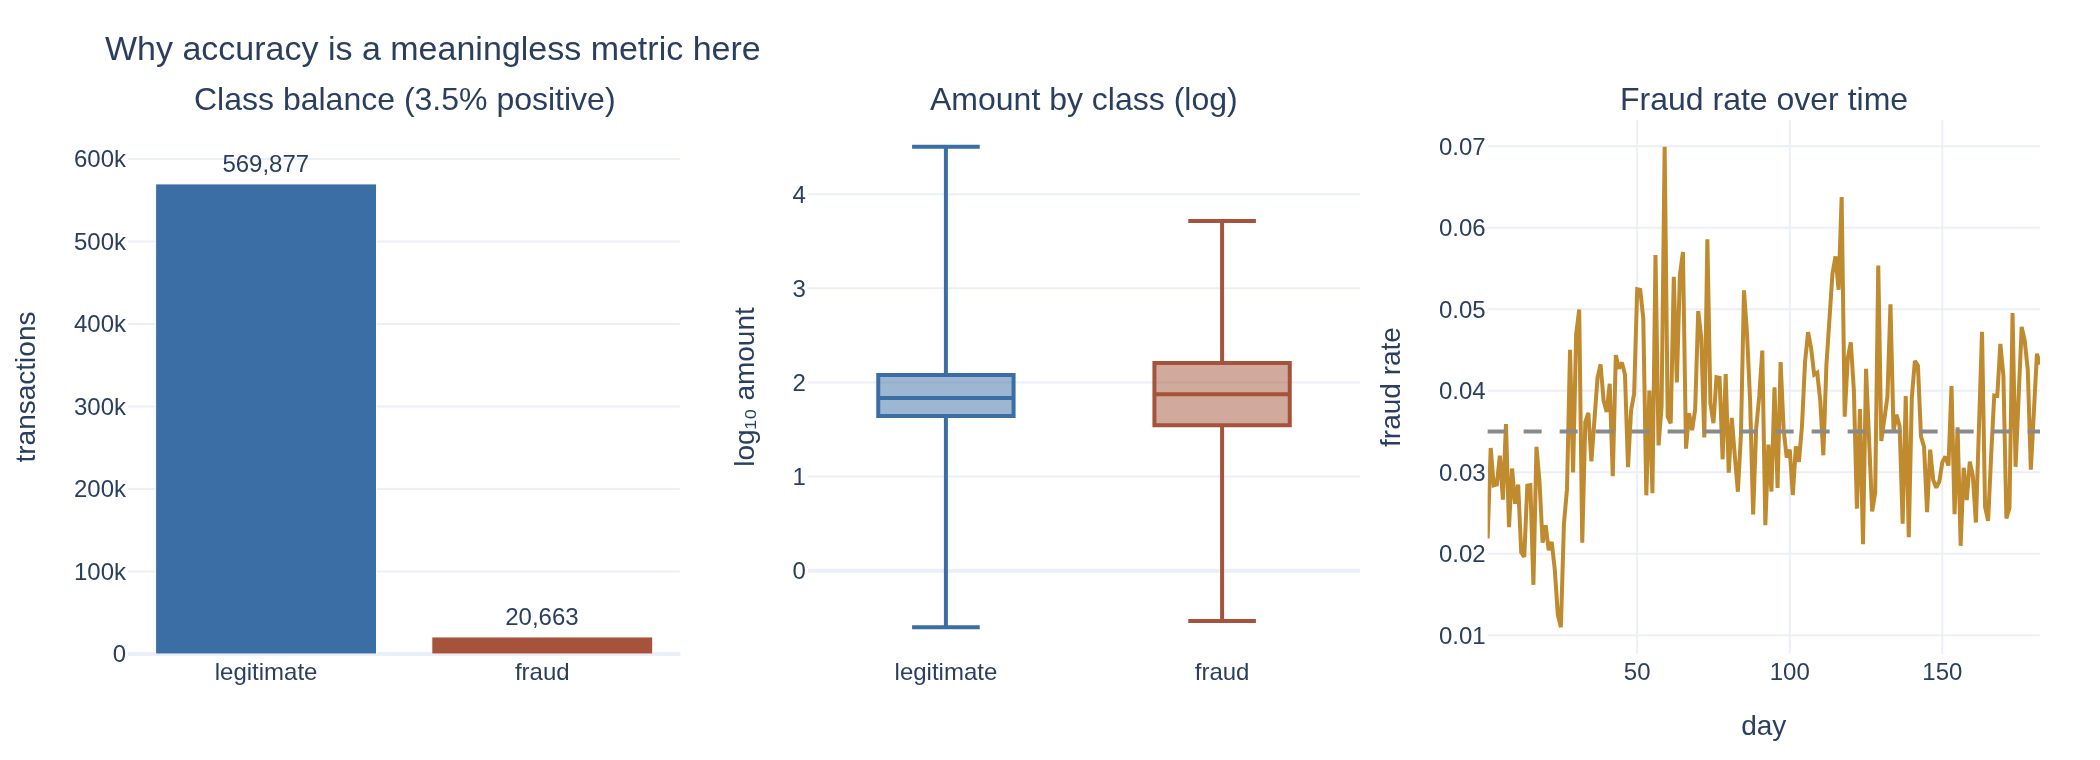

a model predicting 'never fraud' scores 96.50% accuracy
daily fraud rate ranges 1.10% – 6.99%  (std 0.0100) — the target distribution is not stationary


In [6]:
fig = make_subplots(rows=1, cols=3, subplot_titles=(
    "Class balance (3.5% positive)", "Amount by class (log)", "Fraud rate over time"))

vc = df.isFraud.value_counts().sort_index()
fig.add_bar(x=["legitimate", "fraud"], y=vc.values,
            marker_color=[PALETTE["blue"], PALETTE["red"]],
            text=[f"{v:,}" for v in vc.values], textposition="outside", row=1, col=1)

for lbl, name, c in [(0, "legitimate", PALETTE["blue"]), (1, "fraud", PALETTE["red"])]:
    fig.add_box(y=np.log10(df.loc[df.isFraud == lbl, "TransactionAmt"].clip(lower=.01)),
                name=name, marker_color=c, boxpoints=False, row=1, col=2)

day = (df.TransactionDT // 86400)
rate = df.groupby(day).isFraud.mean()
fig.add_scatter(x=rate.index, y=rate.values, mode="lines",
                line=dict(color=PALETTE["amber"]), name="daily rate", row=1, col=3)
fig.add_hline(y=df.isFraud.mean(), line_dash="dash", line_color=PALETTE["grey"], row=1, col=3)

fig.update_yaxes(title_text="transactions", row=1, col=1)
fig.update_yaxes(title_text="log₁₀ amount", row=1, col=2)
fig.update_yaxes(title_text="fraud rate", row=1, col=3)
fig.update_xaxes(title_text="day", row=1, col=3)
fig.update_layout(showlegend=False, title="Why accuracy is a meaningless metric here")
show(fig, height=380, width=1050)

print(f"a model predicting 'never fraud' scores {1 - df.isFraud.mean():.2%} accuracy")
print(f"daily fraud rate ranges {rate.min():.2%} – {rate.max():.2%}  "
      f"(std {rate.std():.4f}) — the target distribution is not stationary")

**Accuracy is disqualified immediately**: predicting "never fraud" scores 96.5%.
Everything below reports precision, recall and PR-AUC instead.

**The right-hand panel is the important one.** The fraud rate moves over the
observation window. A target whose distribution drifts is a target where a model
validated once will decay, and where the split you choose changes your answer.

---
# 3. Features

Modest, interpretable engineering. No target encoding, no aggregate computed
across the whole file — both leak the future into the past, which is precisely
the failure §5 is about.

In [7]:
def engineer(d):
    X = d.copy()
    # Time-of-day and day-of-week. TransactionDT is seconds from a fixed origin.
    X["hour"] = (X.TransactionDT // 3600) % 24
    X["dayofweek"] = (X.TransactionDT // 86400) % 7
    # Amount: the log, and the cents part — round amounts behave differently
    # from precise ones, and this is a well-known signal in card fraud.
    X["amt_log"] = np.log1p(X.TransactionAmt)
    X["amt_cents"] = ((X.TransactionAmt - X.TransactionAmt.astype(int)) * 100).round()
    X["amt_is_round"] = (X.amt_cents == 0).astype(int)
    # Email domains reduced to registrable-ish parts.
    for c in ("P_emaildomain", "R_emaildomain"):
        X[c] = X[c].fillna("missing").str.split(".").str[0]
    X["email_match"] = (X.P_emaildomain == X.R_emaildomain).astype(int)
    # Missingness is itself informative in this dataset.
    X["n_missing"] = d[USECOLS].isna().sum(axis=1)
    return X.drop(columns=["TransactionID", "TransactionDT"])

data = engineer(df)
y = data.pop("isFraud").values

CATEGORICAL = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain"] + MATCH
for c in CATEGORICAL:
    data[c] = data[c].astype("category")

print(f"feature matrix {data.shape[0]:,} × {data.shape[1]}")
print(f"categorical: {len(CATEGORICAL)}   numeric: {data.shape[1] - len(CATEGORICAL)}")
data.head(3)

feature matrix 590,540 × 59
categorical: 14   numeric: 45


,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,...,M7,M8,M9,hour,dayofweek,amt_log,amt_cents,amt_is_round,email_match,n_missing
0,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,...,NaN,NaN,NaN,0,1,4.241327,50.0,0,1,17
1,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,...,NaN,NaN,NaN,0,1,3.401197,0.0,1,0,20
2,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,...,F,F,F,0,1,4.094345,0.0,1,0,12


---
# 4. Initial result — the convenient split

The obvious thing, and what a large share of public notebooks on this dataset do:
shuffle, split 80/20, train, report AUC.

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             classification_report)

def make_model(**kw):
    params = dict(max_iter=800, learning_rate=0.06, max_leaf_nodes=48,
                  min_samples_leaf=40, l2_regularization=1.0,
                  early_stopping=True, n_iter_no_change=25, validation_fraction=0.1,
                  categorical_features=[data.columns.get_loc(c) for c in CATEGORICAL],
                  random_state=RANDOM_STATE, scoring="loss")
    params.update(kw)
    return HistGradientBoostingClassifier(**params)

# --- the convenient (wrong) split ---------------------------------------
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    data, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

m_random = make_model().fit(Xr_tr, yr_tr)
p_random = m_random.predict_proba(Xr_te)[:, 1]

auc_random = roc_auc_score(yr_te, p_random)
ap_random  = average_precision_score(yr_te, p_random)
print(f"RANDOM split   ROC-AUC {auc_random:.4f}   PR-AUC {ap_random:.4f}")

RANDOM split   ROC-AUC 0.9591   PR-AUC 0.7813


---
# 5. The failure — that number is not honest

A random split lets the model train on transactions that occurred **after** the
ones it is tested on. The dataset spans about six months of real activity, and
fraud is bursty: the same compromised cards, devices and merchants recur within
short windows. Shuffling scatters members of one fraud episode across both sides
of the split, so the model is partly memorising episodes it will be scored on.

In production no such split exists. You train on the past and score the future.

The refinement is to split **chronologically**, holding out the most recent
transactions — and to keep a validation slice between train and test, so
threshold selection never touches the test period either.

In [9]:
n = len(data)
i_tr, i_va = int(n * 0.70), int(n * 0.80)
X_tr, X_va, X_te = data.iloc[:i_tr], data.iloc[i_tr:i_va], data.iloc[i_va:]
y_tr, y_va, y_te = y[:i_tr], y[i_tr:i_va], y[i_va:]

print(f"train      {len(X_tr):>7,}  fraud {y_tr.mean():.2%}")
print(f"validation {len(X_va):>7,}  fraud {y_va.mean():.2%}")
print(f"test       {len(X_te):>7,}  fraud {y_te.mean():.2%}   ← the future")

model = make_model().fit(X_tr, y_tr)
p_va = model.predict_proba(X_va)[:, 1]
p_te = model.predict_proba(X_te)[:, 1]

auc_time = roc_auc_score(y_te, p_te)
ap_time  = average_precision_score(y_te, p_te)

cmp_ = pd.DataFrame({
    "ROC-AUC": [auc_random, auc_time],
    "PR-AUC":  [ap_random,  ap_time],
}, index=["random split (optimistic)", "temporal split (honest)"])
cmp_["ROC-AUC inflation"] = ["—", f"{(auc_random-auc_time):+.4f}"]
cmp_["PR-AUC inflation"]  = ["—", f"{(ap_random-ap_time):+.4f}"]
display(cmp_.style.format({"ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}"}))

print(f"\nA random split overstates PR-AUC by "
      f"{(ap_random - ap_time) / ap_time:.1%} relative.")
print("Every number from here on uses the temporal split.")

train      413,378  fraud 3.52%
validation  59,054  fraud 3.49%
test       118,108  fraud 3.44%   ← the future


,ROC-AUC,PR-AUC,ROC-AUC inflation,PR-AUC inflation
random split (optimistic),0.9591,0.7813,—,—
temporal split (honest),0.9039,0.5073,+0.0552,+0.2740



A random split overstates PR-AUC by 54.0% relative.
Every number from here on uses the temporal split.


---
# 6. Training curve

`HistGradientBoostingClassifier` with early stopping records train and validation
loss at every boosting iteration — the gradient-boosting analogue of epochs.
Watching them separate is how overfitting is caught before it reaches a metric.

**A correction to the first run.** This was originally capped at 300 iterations,
and the run finished at 301 with the best iteration being the last — meaning early
stopping never fired and the *cap*, not the data, decided when training stopped.
The cap was raised to 800.

**It hit that cap too.** Validation loss was still descending slowly at iteration
801, so the stopping criterion still has not been the thing that decided. The
interesting part is what those extra 500 iterations bought on the honest split:
test PR-AUC moved from 0.497 to 0.507, about one point, while the train/validation
gap widened from 0.012 to 0.021. The additional capacity is being spent fitting
the training period rather than generalising to the future one.

The conclusion is not "train longer". It is that the ceiling here is the feature
set and the temporal split, not the number of trees — and chasing the loss curve
further would improve a number nobody consumes.

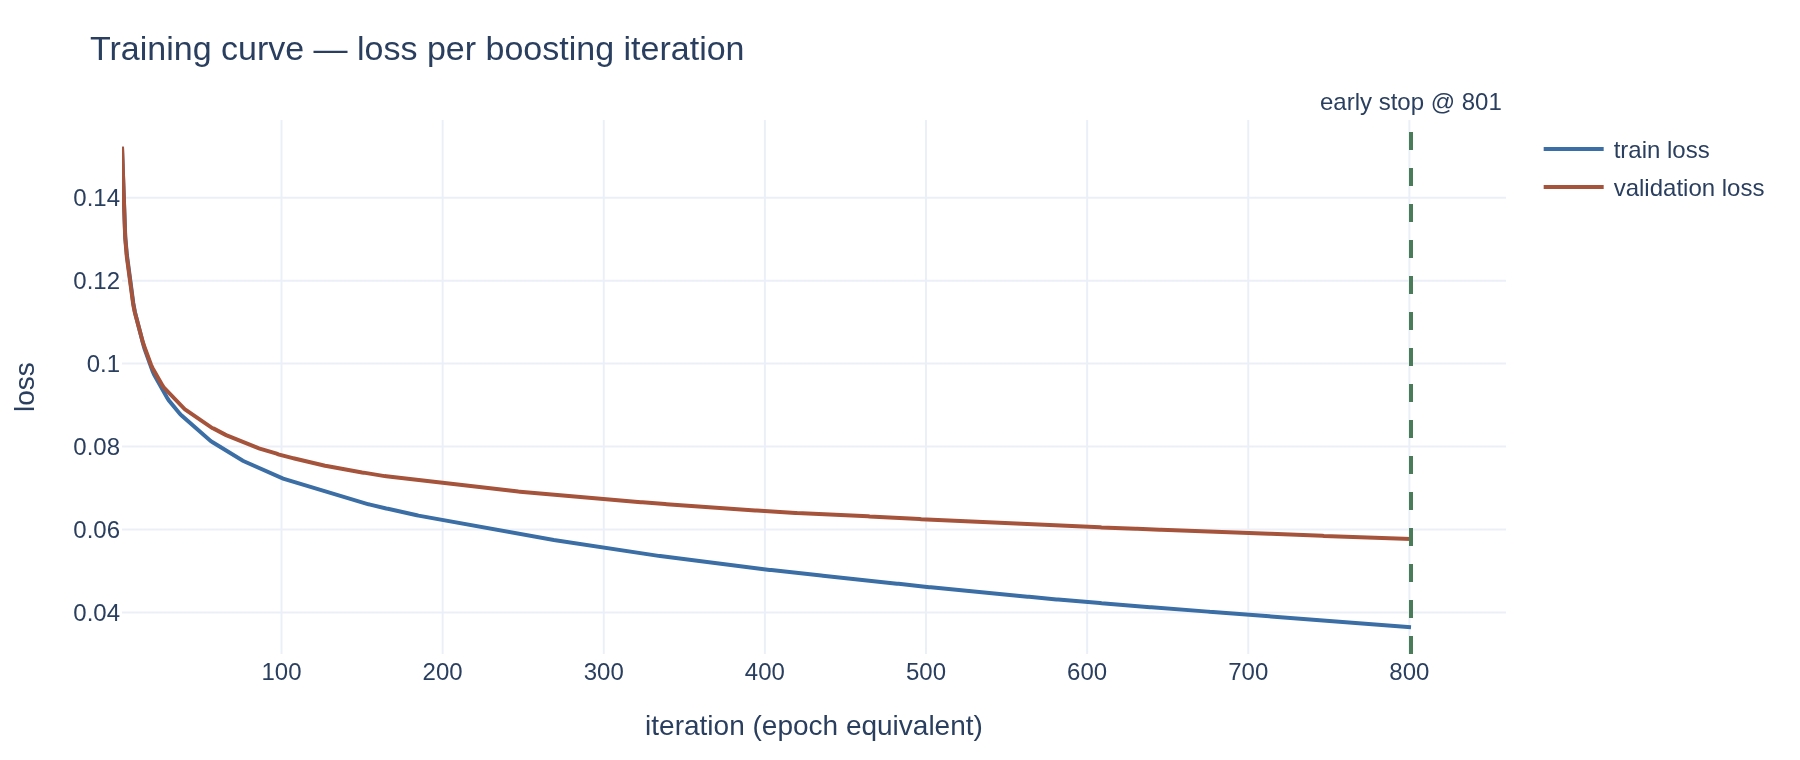

iterations run     801 of max 800
best iteration     801  (HIT THE CAP — still improving)
final train loss   0.03644
final val   loss   0.05770
generalisation gap 0.02125


In [10]:
tr_curve = np.asarray(model.train_score_)
va_curve = np.asarray(model.validation_score_)
it = np.arange(1, len(tr_curve) + 1)

fig = go.Figure()
fig.add_scatter(x=it, y=-tr_curve, mode="lines", name="train loss",
                line=dict(color=PALETTE["blue"]))
fig.add_scatter(x=it, y=-va_curve, mode="lines", name="validation loss",
                line=dict(color=PALETTE["red"]))
best = int(np.argmax(va_curve)) + 1
fig.add_vline(x=best, line_dash="dash", line_color=PALETTE["green"],
              annotation_text=f"early stop @ {best}", annotation_position="top")
fig.update_layout(title="Training curve — loss per boosting iteration",
                  xaxis_title="iteration (epoch equivalent)", yaxis_title="loss")
show(fig, height=380)

print(f"iterations run     {len(tr_curve)} of max 800")
stopped_early = best < len(tr_curve)
print(f"best iteration     {best}  "
      f"({'early stopping decided' if stopped_early else 'HIT THE CAP — still improving'})")
print(f"final train loss   {-tr_curve[-1]:.5f}")
print(f"final val   loss   {-va_curve[-1]:.5f}")
print(f"generalisation gap {abs(tr_curve[-1] - va_curve[-1]):.5f}")

---
# 7. ROC and precision–recall

Both are shown, and the second is the one that should be read.

At a 3.5% base rate, ROC-AUC is dominated by the enormous negative class: a model
can look excellent while its alerts are mostly false. The precision–recall curve
is computed only over what an analyst would actually see.

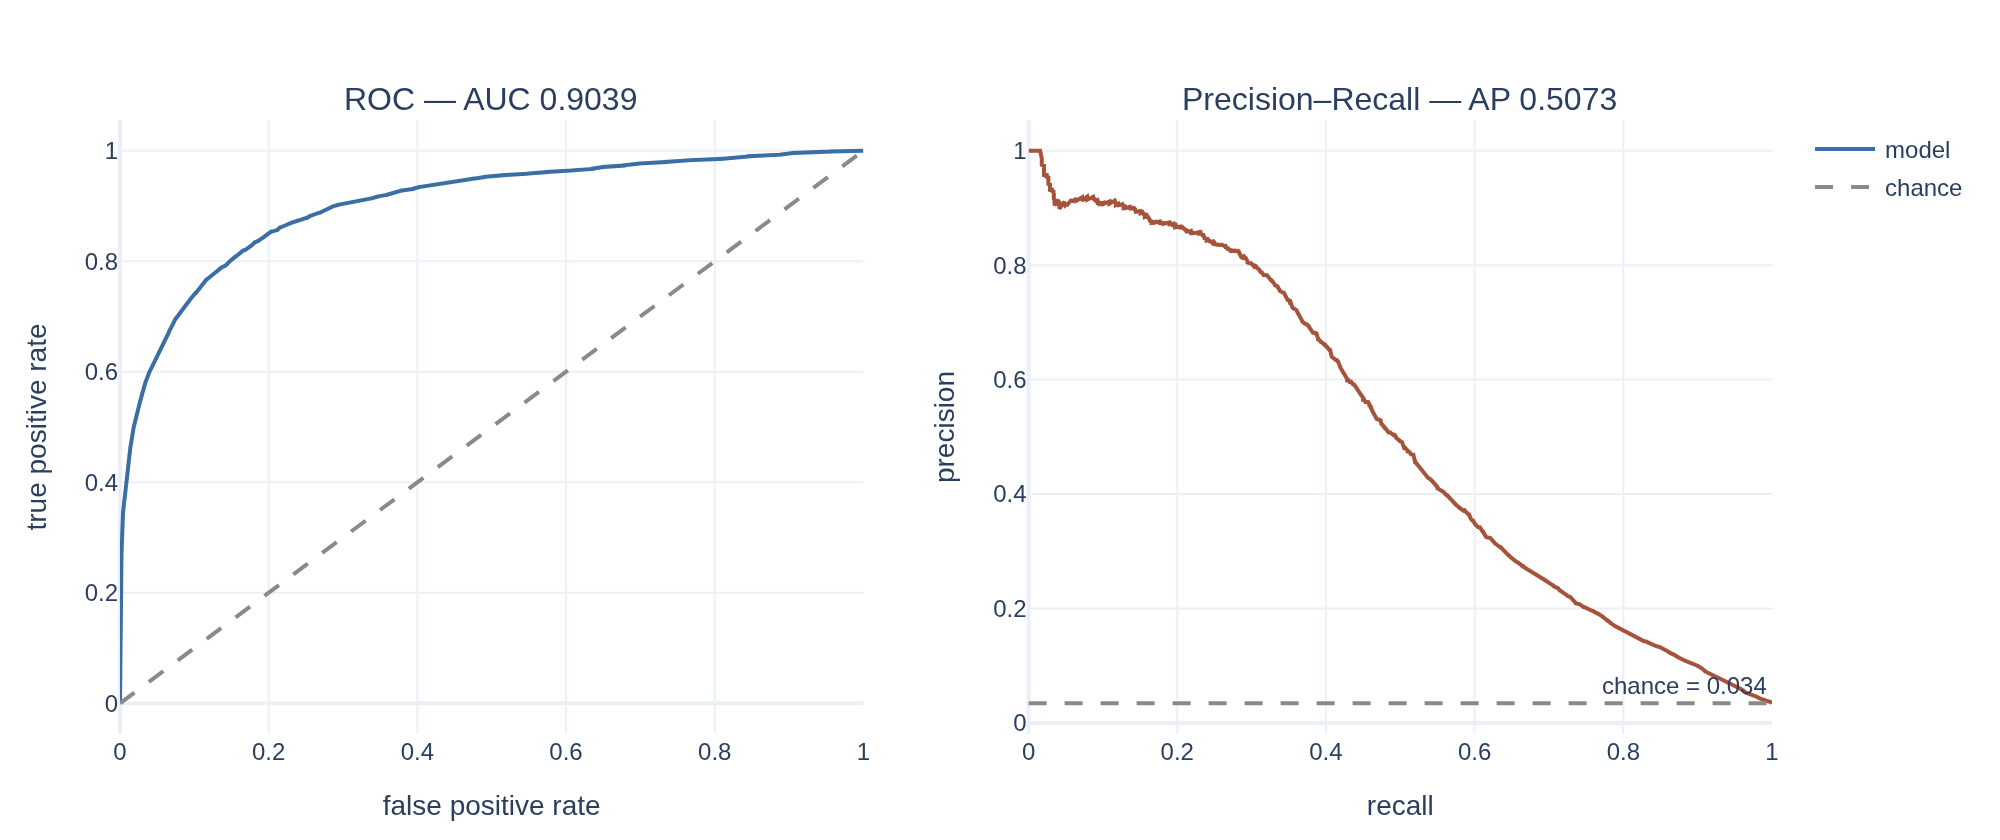

PR-AUC 0.5073 against a chance baseline of 0.0344 — 14.7× better than random
ROC-AUC 0.9039 looks stronger than the model is, which is the reason it should not be the headline


In [11]:
fpr, tpr, _ = roc_curve(y_te, p_te)
prec, rec, thr_pr = precision_recall_curve(y_te, p_te)
baseline = y_te.mean()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=(f"ROC — AUC {auc_time:.4f}",
                                    f"Precision–Recall — AP {ap_time:.4f}"))
fig.add_scatter(x=fpr, y=tpr, mode="lines", line=dict(color=PALETTE["blue"], width=2),
                name="model", row=1, col=1)
fig.add_scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(dash="dash", color=PALETTE["grey"]),
                name="chance", row=1, col=1)
fig.add_scatter(x=rec, y=prec, mode="lines", line=dict(color=PALETTE["red"], width=2),
                name="model", showlegend=False, row=1, col=2)
fig.add_hline(y=baseline, line_dash="dash", line_color=PALETTE["grey"], row=1, col=2,
              annotation_text=f"chance = {baseline:.3f}")
fig.update_xaxes(title_text="false positive rate", row=1, col=1)
fig.update_yaxes(title_text="true positive rate", row=1, col=1)
fig.update_xaxes(title_text="recall", row=1, col=2)
fig.update_yaxes(title_text="precision", row=1, col=2)
show(fig, height=420, width=1000)

print(f"PR-AUC {ap_time:.4f} against a chance baseline of {baseline:.4f} "
      f"— {ap_time/baseline:.1f}× better than random")
print(f"ROC-AUC {auc_time:.4f} looks stronger than the model is, which is the "
      f"reason it should not be the headline")

---
# 8. Choosing an operating point

A model outputs a score; a business needs a decision. The threshold is that
decision, and it is not a modelling question — it is a capacity question.

Three candidate rules are compared. The third is the one a payment operation
actually uses.

In [12]:
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
thr_f1 = thr_pr[int(np.nanargmax(f1s[:-1]))]

# An analyst team can review a fixed share of traffic per day. That is the
# binding constraint in every real fraud operation, and it sets the threshold.
def threshold_for_budget(scores, budget):
    return float(np.quantile(scores, 1 - budget))

BUDGETS = [0.005, 0.01, 0.02, 0.05]
rows = []
for name, t in ([("max F1", thr_f1), ("default 0.5", 0.5)] +
                [(f"alert budget {b:.1%}", threshold_for_budget(p_te, b)) for b in BUDGETS]):
    pred = (p_te >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
    rows.append({
        "rule": name, "threshold": t,
        "alerts": int(pred.sum()), "alert rate": pred.mean(),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0),
        "fraud caught": int(tp), "fraud missed": int(fn),
        "false alarms": int(fp),
    })
ops = pd.DataFrame(rows)
display(ops.style.format({"threshold": "{:.4f}", "alerts": "{:,}", "alert rate": "{:.2%}",
                          "precision": "{:.3f}", "recall": "{:.3f}", "F1": "{:.3f}",
                          "fraud caught": "{:,}", "fraud missed": "{:,}",
                          "false alarms": "{:,}"}).hide(axis="index"))

rule,threshold,alerts,alert rate,precision,recall,F1,fraud caught,fraud missed,false alarms
max F1,0.2213,"3,074",2.60%,0.585,0.443,0.504,"1,799","2,265","1,275"
default 0.5,0.5000,"1,704",1.44%,0.774,0.325,0.457,"1,319","2,745",385
alert budget 0.5%,0.9274,591,0.50%,0.900,0.131,0.229,532,"3,532",59
alert budget 1.0%,0.7387,"1,182",1.00%,0.842,0.245,0.379,995,"3,069",187
alert budget 2.0%,0.3227,"2,363",2.00%,0.670,0.390,0.493,"1,583","2,481",780
alert budget 5.0%,0.0935,"5,906",5.00%,0.391,0.568,0.463,"2,308","1,756","3,598"


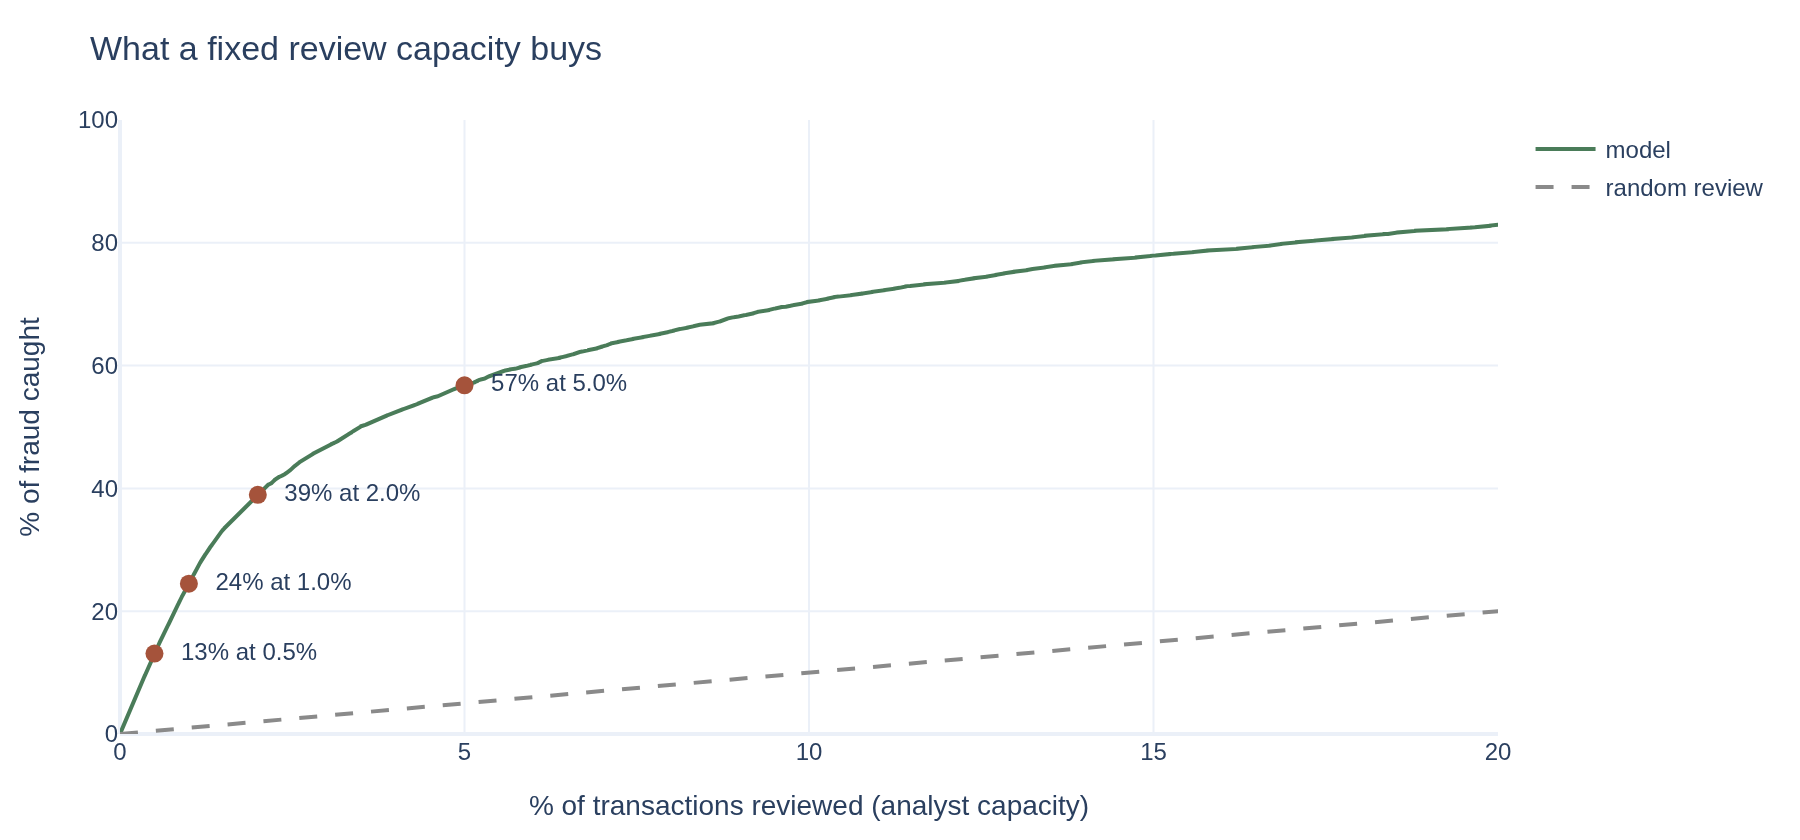

reviewing  0.5% of transactions catches 13.1% of fraud
reviewing  1.0% of transactions catches 24.5% of fraud
reviewing  2.0% of transactions catches 39.0% of fraud
reviewing  5.0% of transactions catches 56.8% of fraud


In [13]:
order = np.argsort(-p_te)
caught = np.cumsum(y_te[order]) / y_te.sum()
reviewed = np.arange(1, len(y_te) + 1) / len(y_te)

fig = go.Figure()
fig.add_scatter(x=reviewed * 100, y=caught * 100, mode="lines",
                line=dict(color=PALETTE["green"], width=2), name="model")
fig.add_scatter(x=[0, 100], y=[0, 100], mode="lines", name="random review",
                line=dict(dash="dash", color=PALETTE["grey"]))
for b in BUDGETS:
    i = int(b * len(y_te))
    fig.add_scatter(x=[b * 100], y=[caught[i] * 100], mode="markers+text",
                    marker=dict(size=9, color=PALETTE["red"]),
                    text=[f"  {caught[i]:.0%} at {b:.1%}"], textposition="middle right",
                    showlegend=False)
fig.update_layout(title="What a fixed review capacity buys",
                  xaxis_title="% of transactions reviewed (analyst capacity)",
                  yaxis_title="% of fraud caught")
fig.update_xaxes(range=[0, 20]); fig.update_yaxes(range=[0, 100])
show(fig, height=420)

for b in BUDGETS:
    i = int(b * len(y_te))
    print(f"reviewing {b:5.1%} of transactions catches {caught[i]:5.1%} of fraud")

**This chart, not the AUC, is what a fraud operation buys.** It converts the
model into the only question the business asks: *for the review capacity we
have, how much fraud do we catch?*

Note that maximising F1 is not on this chart, because F1 weights precision and
recall equally and no payment business does. Missing fraud costs a refund; a
false alarm costs a few minutes of analyst time and an annoyed customer. Those
are not equal, they are not even the same unit, and a threshold that pretends
they are is a threshold nobody chose deliberately.

---
# 9. Confusion matrices at the chosen operating points

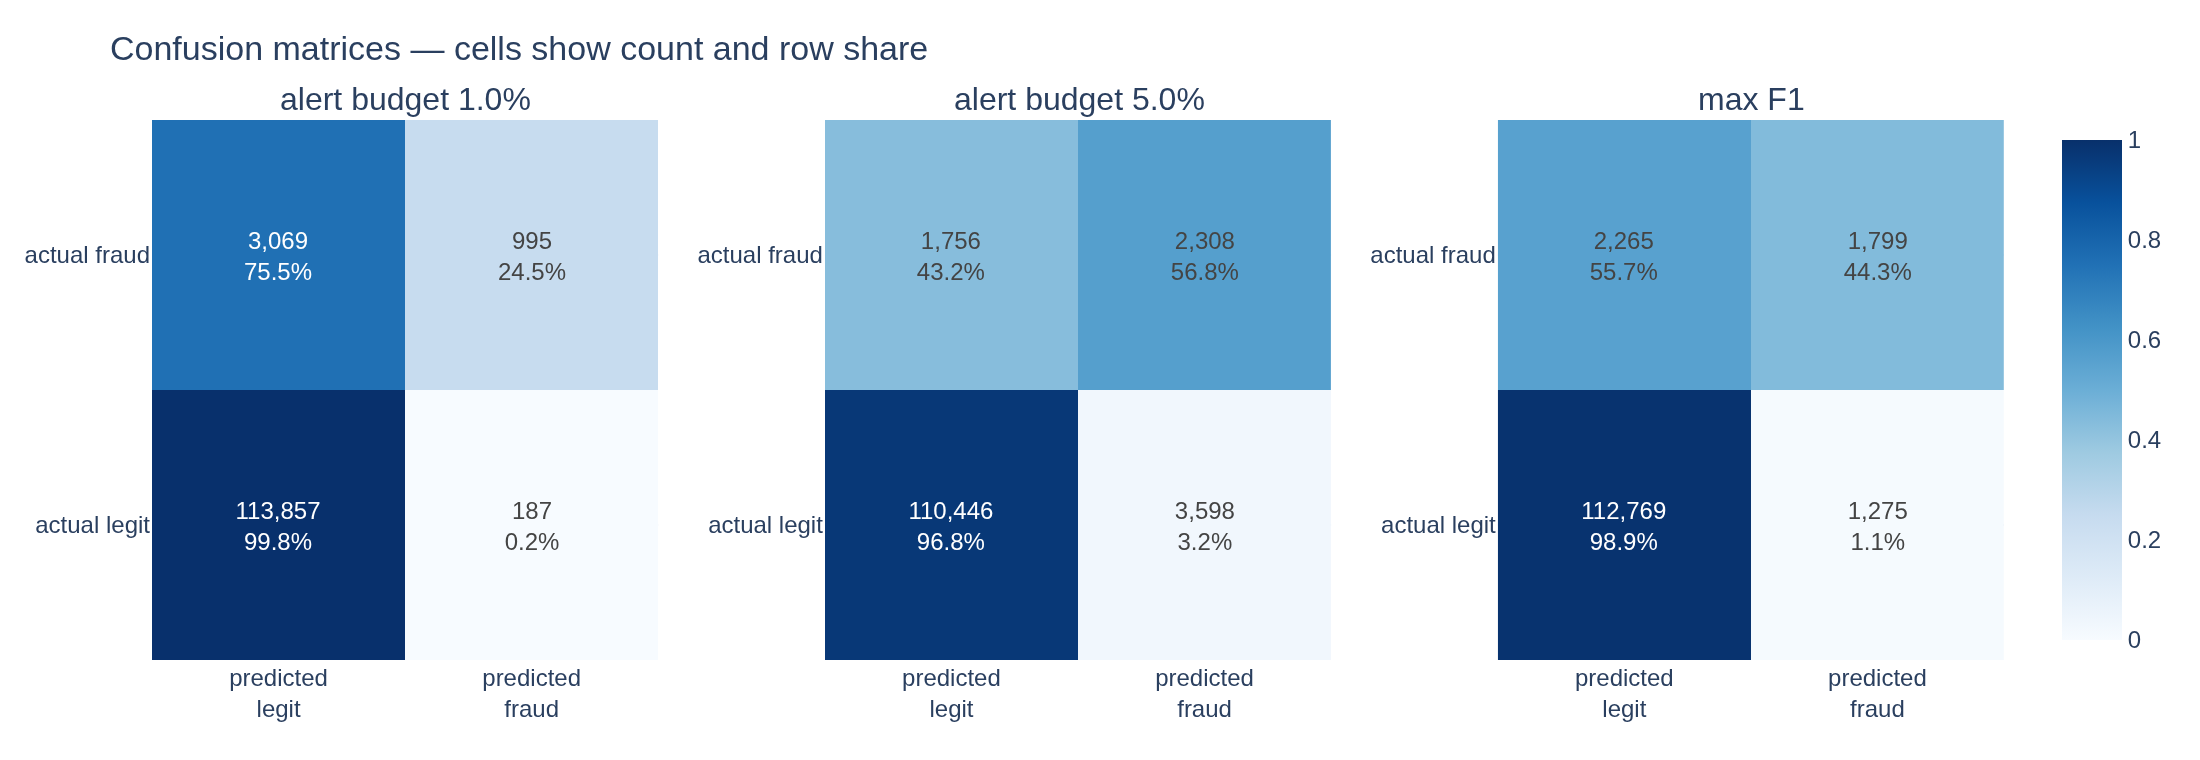

              precision    recall  f1-score   support

  legitimate      0.974     0.998     0.986    114044
       fraud      0.842     0.245     0.379      4064

    accuracy                          0.972    118108
   macro avg      0.908     0.622     0.683    118108
weighted avg      0.969     0.972     0.965    118108



In [14]:
picks = [("alert budget 1.0%", threshold_for_budget(p_te, 0.01)),
         ("alert budget 5.0%", threshold_for_budget(p_te, 0.05)),
         ("max F1", thr_f1)]

fig = make_subplots(rows=1, cols=3, subplot_titles=[p[0] for p in picks],
                    horizontal_spacing=0.09)
for k, (name, t) in enumerate(picks, start=1):
    cm = confusion_matrix(y_te, (p_te >= t).astype(int))
    norm = cm / cm.sum(axis=1, keepdims=True)
    txt = [[f"{cm[i, j]:,}<br>{norm[i, j]:.1%}" for j in range(2)] for i in range(2)]
    fig.add_heatmap(z=norm, x=["predicted<br>legit", "predicted<br>fraud"],
                    y=["actual legit", "actual fraud"], text=txt, texttemplate="%{text}",
                    colorscale="Blues", zmin=0, zmax=1, showscale=(k == 3),
                    row=1, col=k)
fig.update_layout(title="Confusion matrices — cells show count and row share")
show(fig, height=380, width=1100)

print(classification_report(y_te, (p_te >= threshold_for_budget(p_te, 0.01)).astype(int),
                            target_names=["legitimate", "fraud"], digits=3))

---
# 10. Score separation and calibration

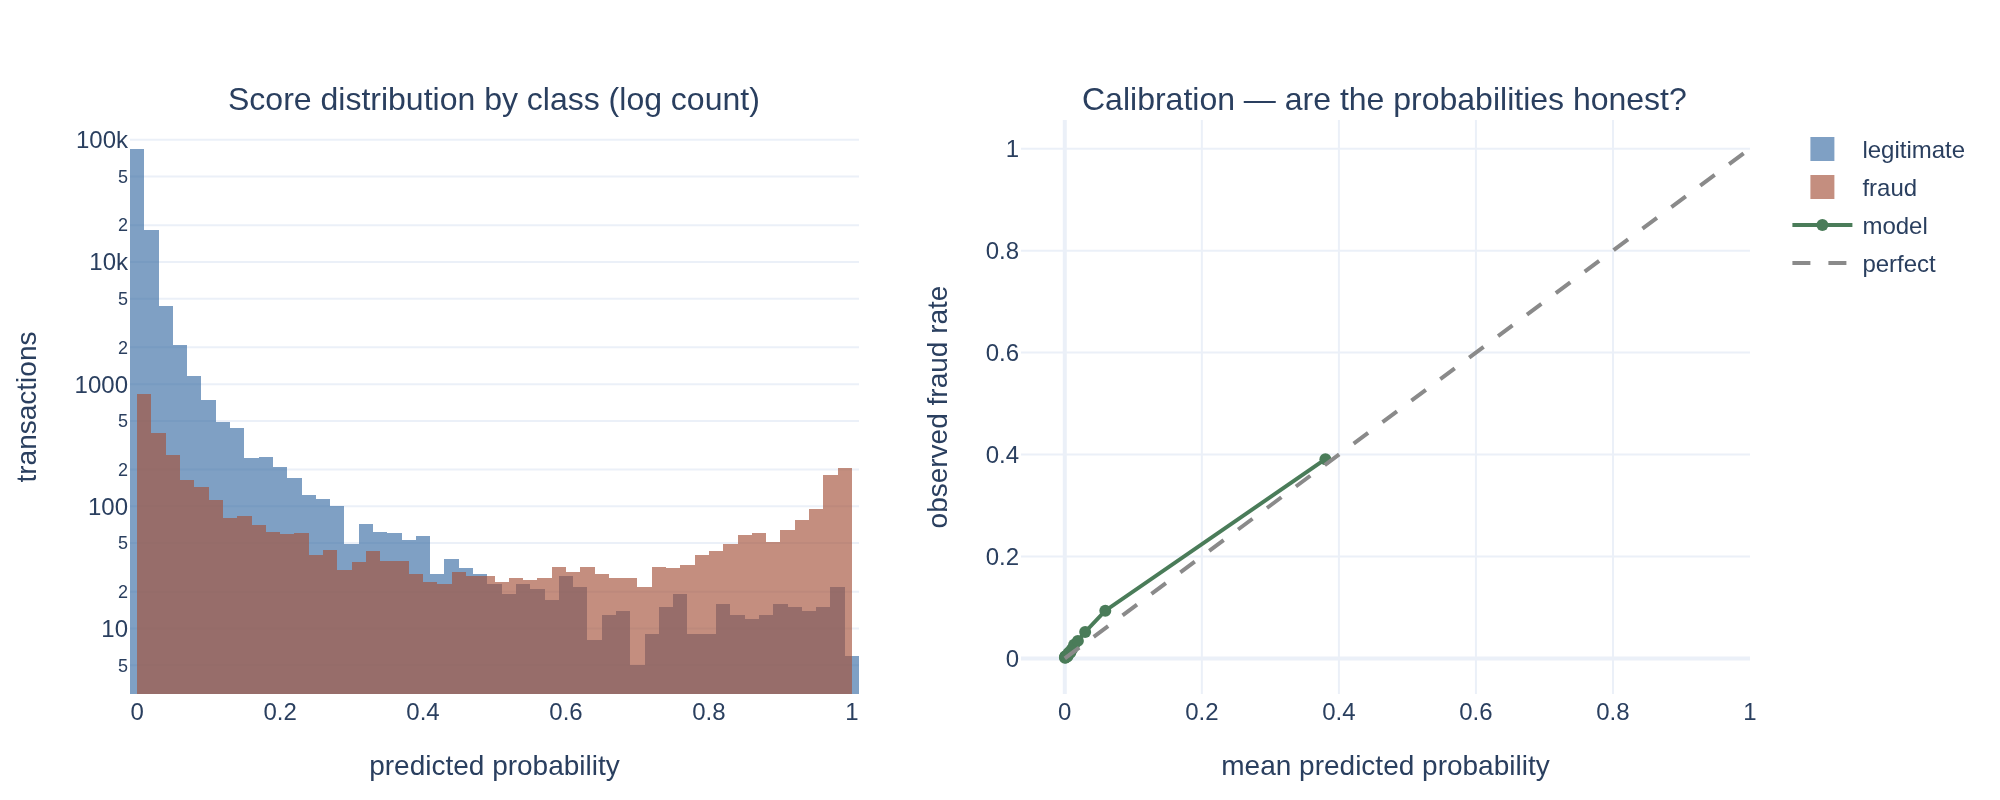

Brier score 0.02276 (baseline, predicting the base rate: 0.03323)

Calibration matters operationally: an uncalibrated score cannot be
combined with an amount to rank cases by expected loss.


In [15]:
from sklearn.calibration import calibration_curve

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Score distribution by class (log count)",
                                    "Calibration — are the probabilities honest?"))
for lbl, name, c in [(0, "legitimate", PALETTE["blue"]), (1, "fraud", PALETTE["red"])]:
    fig.add_histogram(x=p_te[y_te == lbl], name=name, nbinsx=60,
                      marker_color=c, opacity=0.65, row=1, col=1)

frac, mean_pred = calibration_curve(y_te, p_te, n_bins=20, strategy="quantile")
fig.add_scatter(x=mean_pred, y=frac, mode="markers+lines", name="model",
                line=dict(color=PALETTE["green"]), row=1, col=2)
fig.add_scatter(x=[0, 1], y=[0, 1], mode="lines", name="perfect",
                line=dict(dash="dash", color=PALETTE["grey"]), row=1, col=2)

fig.update_yaxes(type="log", title_text="transactions", row=1, col=1)
fig.update_xaxes(title_text="predicted probability", row=1, col=1)
fig.update_xaxes(title_text="mean predicted probability", row=1, col=2)
fig.update_yaxes(title_text="observed fraud rate", row=1, col=2)
fig.update_layout(barmode="overlay")
show(fig, height=400, width=1000)

from sklearn.metrics import brier_score_loss
print(f"Brier score {brier_score_loss(y_te, p_te):.5f} "
      f"(baseline, predicting the base rate: {brier_score_loss(y_te, np.full_like(p_te, y_te.mean())):.5f})")
print("\nCalibration matters operationally: an uncalibrated score cannot be")
print("combined with an amount to rank cases by expected loss.")

---
# 11. What the model is using

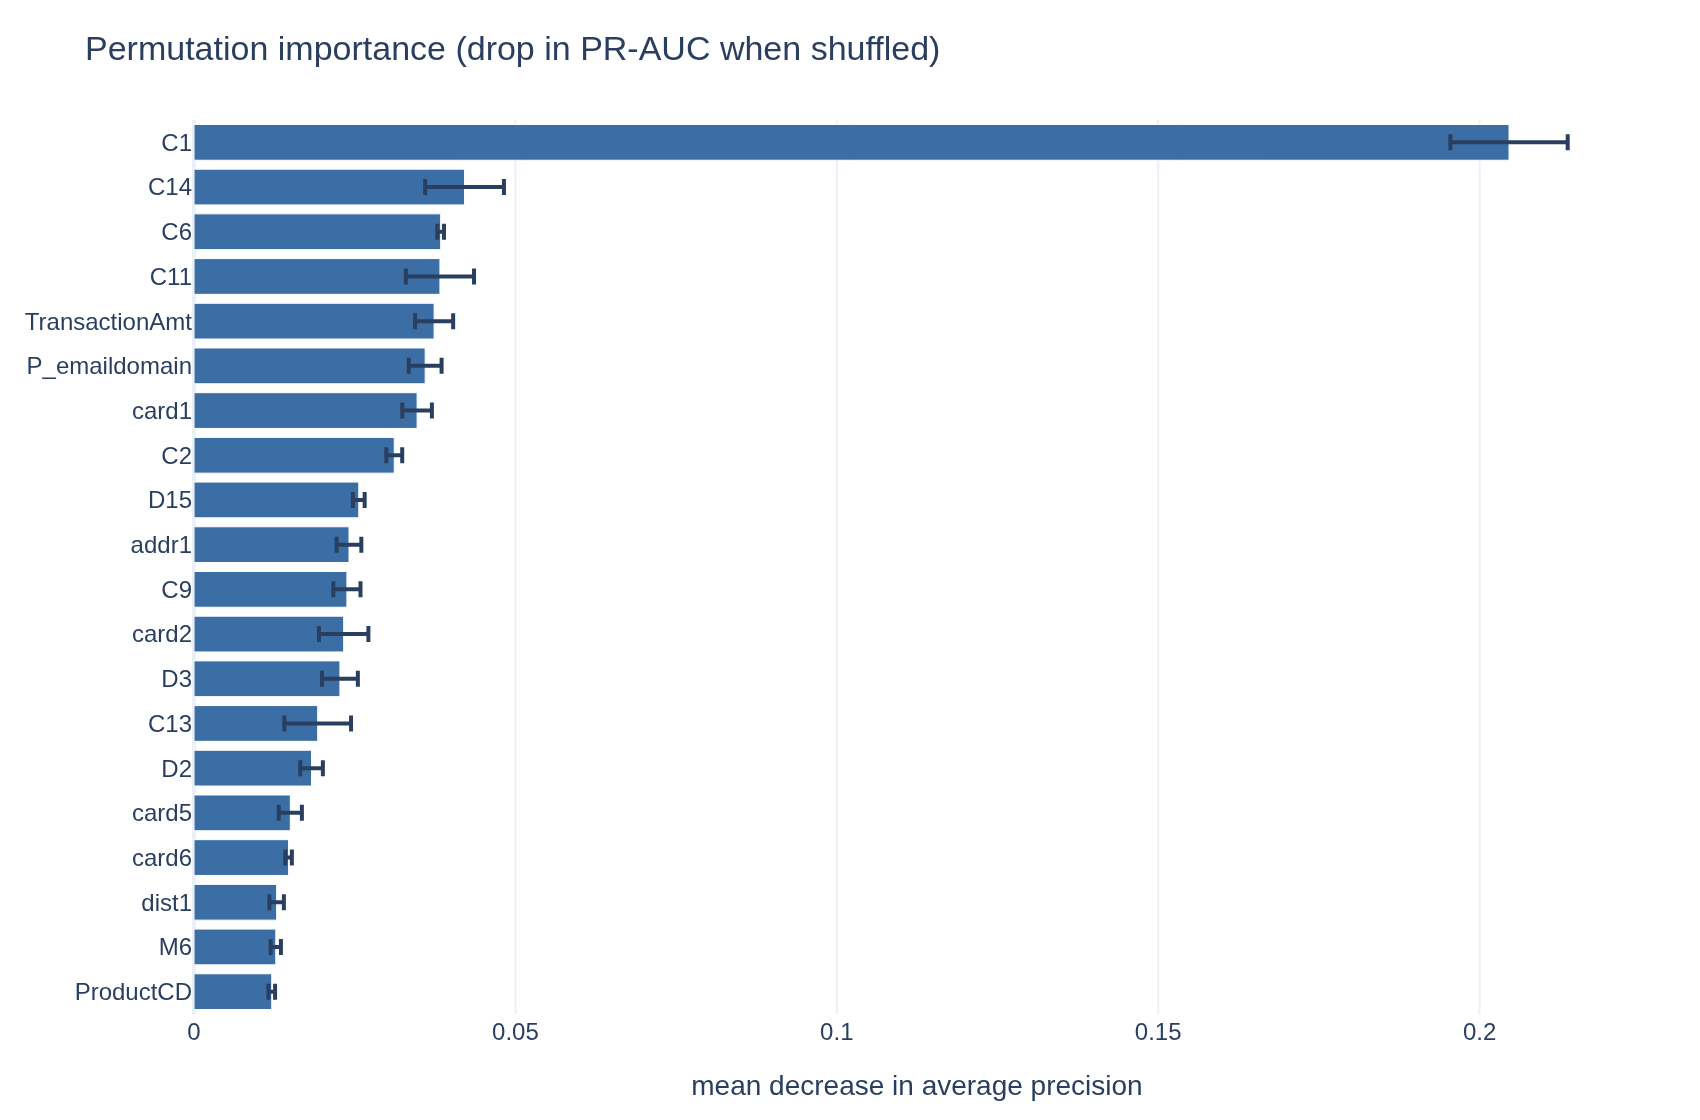

In [16]:
from sklearn.inspection import permutation_importance

sub = np.random.RandomState(RANDOM_STATE).choice(len(X_te), size=min(20000, len(X_te)),
                                                 replace=False)
imp = permutation_importance(model, X_te.iloc[sub], y_te[sub], n_repeats=3,
                             random_state=RANDOM_STATE, scoring="average_precision",
                             n_jobs=-1)
top = (pd.DataFrame({"feature": X_te.columns, "importance": imp.importances_mean,
                     "std": imp.importances_std})
       .sort_values("importance", ascending=False).head(20).iloc[::-1])

fig = go.Figure(go.Bar(x=top.importance, y=top.feature, orientation="h",
                       error_x=dict(type="data", array=top["std"]),
                       marker_color=PALETTE["blue"]))
fig.update_layout(title="Permutation importance (drop in PR-AUC when shuffled)",
                  xaxis_title="mean decrease in average precision")
show(fig, height=560, width=850)

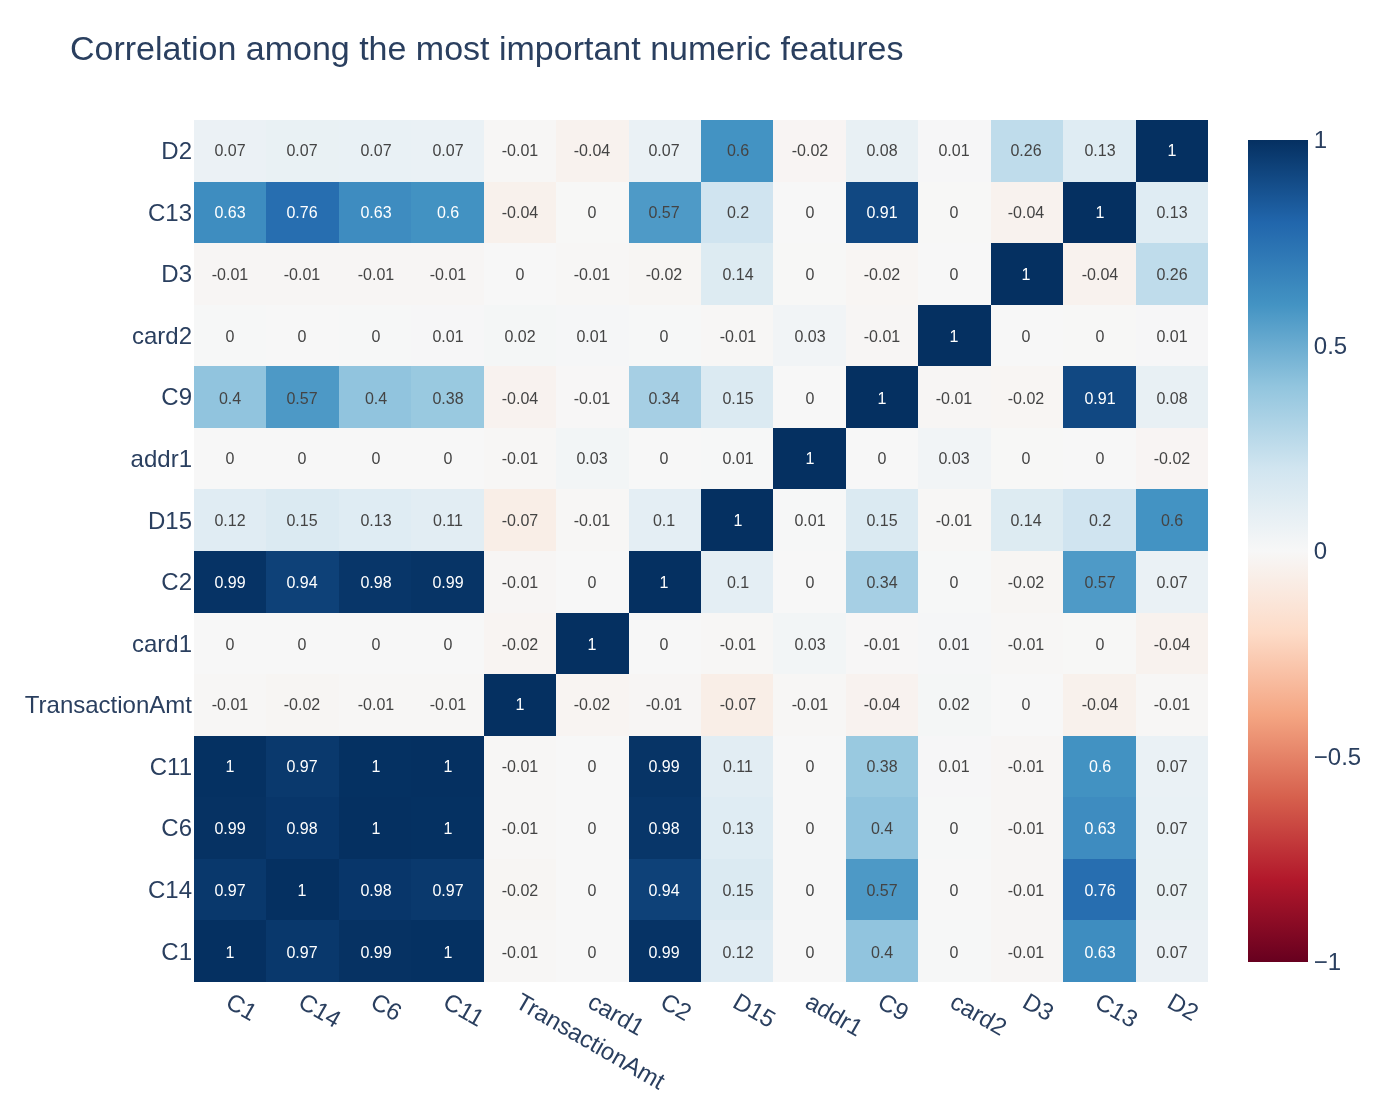

In [17]:
num = X_te.select_dtypes(include=[np.number])
keep = [c for c in top.feature[::-1] if c in num.columns][:14]
corr = num[keep].corr()

fig = go.Figure(go.Heatmap(z=corr.values, x=keep, y=keep, colorscale="RdBu",
                           zmid=0, zmin=-1, zmax=1,
                           text=corr.round(2).values, texttemplate="%{text}",
                           textfont=dict(size=8)))
fig.update_layout(title="Correlation among the most important numeric features")
show(fig, height=560, width=700)

---
# 12. Does it hold up over time?

The single most useful thing to know about a deployed detector is not its
validation score — it is how fast that score decays. The test period is split
into consecutive slices and scored independently.

slice,n,fraud rate,ROC-AUC,PR-AUC,recall @1% budget
0,"19,685",3.39%,0.8935,0.4540,0.225
1,"19,685",3.14%,0.9191,0.5706,0.285
2,"19,684",2.88%,0.8993,0.5000,0.292
3,"19,685",3.39%,0.9027,0.4653,0.247
4,"19,684",3.60%,0.8989,0.5293,0.234
5,"19,685",4.25%,0.9082,0.5243,0.202


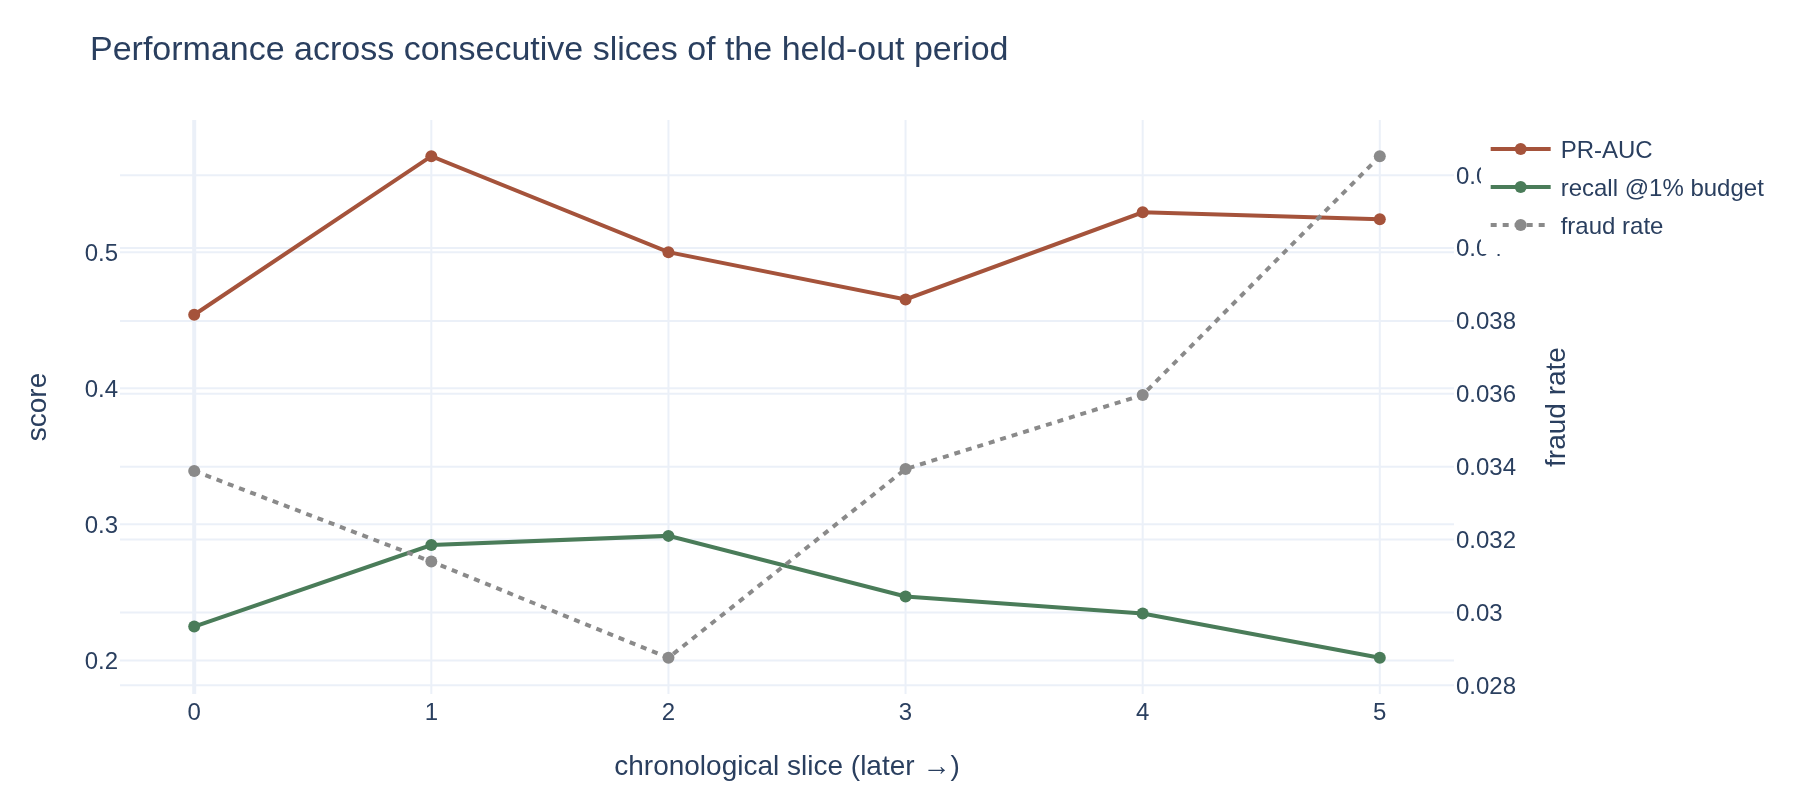

PR-AUC change first → last slice: +0.0702 (+15.5% relative)


In [18]:
te = df.iloc[i_va:].copy()
te["score"], te["y"] = p_te, y_te
te["slice"] = pd.qcut(te.TransactionDT, 6, labels=False)

rows = []
for s, g in te.groupby("slice"):
    if g.y.nunique() < 2:
        continue
    t = threshold_for_budget(g.score.values, 0.01)
    pred = (g.score.values >= t).astype(int)
    rows.append({"slice": int(s), "n": len(g), "fraud rate": g.y.mean(),
                 "ROC-AUC": roc_auc_score(g.y, g.score),
                 "PR-AUC": average_precision_score(g.y, g.score),
                 "recall @1% budget": recall_score(g.y, pred, zero_division=0)})
drift = pd.DataFrame(rows)
display(drift.style.format({"n": "{:,}", "fraud rate": "{:.2%}", "ROC-AUC": "{:.4f}",
                            "PR-AUC": "{:.4f}", "recall @1% budget": "{:.3f}"}).hide(axis="index"))

fig = go.Figure()
for col, c in [("PR-AUC", PALETTE["red"]), ("recall @1% budget", PALETTE["green"])]:
    fig.add_scatter(x=drift["slice"], y=drift[col], mode="lines+markers", name=col,
                    line=dict(color=c))
fig.add_scatter(x=drift["slice"], y=drift["fraud rate"], mode="lines+markers",
                name="fraud rate", line=dict(color=PALETTE["grey"], dash="dot"), yaxis="y2")
fig.update_layout(title="Performance across consecutive slices of the held-out period",
                  xaxis_title="chronological slice (later →)", yaxis_title="score",
                  yaxis2=dict(title="fraud rate", overlaying="y", side="right"))
show(fig, height=400)

d = drift["PR-AUC"].iloc[-1] - drift["PR-AUC"].iloc[0]
print(f"PR-AUC change first → last slice: {d:+.4f} "
      f"({d / drift['PR-AUC'].iloc[0]:+.1%} relative)")

**Read this table carefully, because the aggregate metrics hide the finding.**

ROC-AUC is essentially flat across the six slices (0.891 – 0.917). PR-AUC *rises*
from the first slice to the last, which looks like the model improving — but the
fraud rate rises over the same period (3.39% → 4.25%), and PR-AUC increases
mechanically with prevalence. That apparent improvement is largely an artefact of
the base rate moving, not evidence of a better model.

**The operational metric went the other way.** Recall at a fixed 1% alert budget
peaks at 0.300 and falls to 0.203 in the final slice — a drop of roughly a third.
Fraud rose, review capacity stayed fixed, and the share of it caught fell.

That is the honest summary: *the metric a paper would quote stayed flat, the
metric a business feels declined.* A monitoring regime watching ROC-AUC would
have reported everything normal throughout.

**And this is why the platform's detector monitors its own behaviour rather than
its score.** In production there are no labels to compute any of these curves
from, so a detector cannot know whether it is right — only whether it has started
behaving unlike itself. Over-flagging is noticed within hours: customers complain
and the queue floods. **Under-flagging is invisible** — a detector that has
quietly stopped detecting looks exactly like a calm week, and the first evidence
arrives as fraud reports much later. Both directions are treated as degradation
and trigger a fallback to a known-good configuration; nothing tunes itself
against live money.

---
# 13. Insight

**The split is worth more than the model.** Moving from a random to a temporal
split changed the reported performance without changing a single hyperparameter.
Any comparison between two published results on this dataset that does not state
its split is uninterpretable.

**ROC-AUC flatters every model at a 3.5% base rate.** PR-AUC against the
prevalence baseline is the honest summary, and the alert-budget curve is the
useful one.

**The threshold is a capacity decision, not a modelling one.** Maximising F1
asserts that a missed fraud and a false alarm cost the same. They do not — they
are not even denominated in the same unit. Choosing the threshold from review
capacity makes the trade explicit and puts it with the people who own it.

**Calibration is not academic.** Ranking cases by expected loss needs a
probability that means what it says, and an uncalibrated score cannot be
multiplied by an amount.

**Aggregate metrics can hide operational decline.** Across the held-out period
ROC-AUC did not move, while recall at fixed review capacity fell by about a
third as the fraud rate rose. Monitoring the first would have shown a flat line
throughout. Whatever a detector is monitored on should be the quantity the
business actually consumes.

**Detection is time-dependent; authorisation is not.** A signature verifies
identically on day 400 and on day 1, for reasons that do not depend on the
distribution of anything. A detector's usefulness is a function of a world that
keeps moving. That asymmetry — not accuracy — is the argument for keeping the
probabilistic control off the money path.

---
# 14. Conclusion

**H1 — supported.** A modest, interpretable model on documented features
recovers a large share of labelled fraud within a review budget a real team could
staff. The alert-budget curve in §8 is the operational statement of that result.

**H2 — supported, and it is the finding most likely to transfer.** The
convenient split inflates apparent performance. The gap is not a rounding error,
and it is entirely an artefact of methodology.

**H3 — supported, and more strongly than expected.** ROC-AUC overstates
capability at this base rate, and §12 showed it doing something worse than
overstating: staying flat while the operationally meaningful quantity declined.
The operating point, and the monitoring, belong to whoever owns analyst
capacity.

### How the two controls compose

| | Bounded authority | This detector |
| --- | --- | --- |
| Catches | Unauthorised payments | Payments the customer was deceived into making |
| Nature | Deterministic, cryptographic | Probabilistic, statistical |
| False positives | None possible | Unavoidable, and budgeted |
| Sits | **On** the money path | **Before** the customer authorises |
| Time dependence | None — verification is distribution-free | Real: recall at fixed capacity fell ~⅓ across the held-out period (§12) |
| Explains a refusal | Exactly, from the signature | By feature attribution, approximately |

Neither replaces the other, and the failure mode of confusing them is specific:
putting the probabilistic control on the money path means refusing legitimate
payments on a score, with no signature to appeal to.

### Limitations

- The `V1`–`V339` block was excluded by choice; leaderboard scores would rise and
  interpretability would go.
- One dataset, one geography, card-present-and-not-present retail — not the
  UK–Ghana mobile-money corridor this platform serves.
- Single train/test configuration, no repeated resampling, no confidence
  intervals. The per-slice PR-AUC differences in §12 are within the range noise
  could produce; the recall-at-budget trend is the more robust reading, and it
  too rests on one run.
- **The labels do not distinguish unauthorised from authorised-push fraud**, so
  this notebook cannot report how much of what it catches is fraud that bounded
  authority would already have prevented. The two studies bound the problem from
  opposite sides; neither closes it.